INITIAL SANITY CHECK

In [ ]:
# Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
raw_data = pd.read_csv('/content/drive/MyDrive/kaggle 2025-2026 india.csv')
raw_data.head()

,city,state,Latitude,Longitude,timestamp,PM2.5,PM10,CO,NO2,SO2,O3
0,Agartala,Tripura,23.8315,91.2868,08/05/2022 0:00,14.8,21.5,197,21.8,2.7,32
1,Agartala,Tripura,23.8315,91.2868,08/05/2022 1:00,15.7,22.8,196,18.5,3.0,33
2,Agartala,Tripura,23.8315,91.2868,08/05/2022 2:00,16.3,23.5,196,15.1,3.3,34
3,Agartala,Tripura,23.8315,91.2868,08/05/2022 3:00,17.6,25.4,197,14.1,3.3,32
4,Agartala,Tripura,23.8315,91.2868,08/05/2022 4:00,18.2,26.2,199,13.9,3.2,30


In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
raw_data = raw_data.sort_values(by='timestamp')
raw_data.head(10)

,city,state,Latitude,Longitude,timestamp,PM2.5,PM10,CO,NO2,SO2,O3
119736,Bhopal,Madhya Pradesh,23.2599,77.4126,01/01/2023 0:00,43.0,63.1,406,8.2,4.2,63
468216,Jaipur,Rajasthan,26.9124,75.7873,01/01/2023 0:00,55.9,82.9,1054,49.5,8.5,22
439176,Itanagar,Arunachal Pradesh,27.0844,93.6053,01/01/2023 0:00,15.4,22.2,218,3.3,0.6,52
410136,Imphal,Manipur,24.8170,93.9368,01/01/2023 0:00,38.2,54.7,470,8.7,7.6,64
642456,Patna,Bihar,25.5941,85.1376,01/01/2023 0:00,236.1,339.0,2480,88.7,40.2,15
177816,Chandigarh,Punjab,30.7333,76.7794,01/01/2023 0:00,63.1,90.3,1603,75.2,19.8,1
816696,Visakhapatnam,Andhra Pradesh,17.6868,83.2185,01/01/2023 0:00,80.8,120.1,2987,51.3,88.2,56
61656,Aizawl,Mizoram,23.7271,92.7176,01/01/2023 0:00,26.8,38.6,502,17.8,1.8,38
497256,Kohima,Nagaland,25.6751,94.1086,01/01/2023 0:00,26.5,38.0,574,15.1,1.2,38
584376,Mumbai,Maharashtra,19.0760,72.8777,01/01/2023 0:00,50.4,76.4,723,51.2,102.1,37


In [ ]:
raw_data.duplicated().sum()

np.int64(0)

In [ ]:
raw_data.isna().sum()

,0
city,0
state,0
Latitude,0
Longitude,0
timestamp,0
PM2.5,0
PM10,0
CO,0
NO2,0
SO2,0


In [ ]:
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'], errors='coerce')
raw_data.dtypes

,0
city,object
state,object
Latitude,float64
Longitude,float64
timestamp,datetime64[ns]
PM2.5,float64
PM10,float64
CO,int64
NO2,float64
SO2,float64


In [ ]:
# Desired column order
desired_order = [
    'timestamp',
    'state', 'city', 'Latitude','Longitude',
    'PM2.5',
    'PM10',
    'NO2',
    'SO2',
   'O3',
   'CO'
]

# keep only columns that actually exist in the dataframe
existing_cols = [col for col in desired_order if col in raw_data.columns]

# final reordered dataframe
raw_data = raw_data[existing_cols]

raw_data.head()

,timestamp,state,city,Latitude,Longitude,PM2.5,PM10,NO2,SO2,O3,CO
119736,2023-01-01,Madhya Pradesh,Bhopal,23.2599,77.4126,43.0,63.1,8.2,4.2,63,406
468216,2023-01-01,Rajasthan,Jaipur,26.9124,75.7873,55.9,82.9,49.5,8.5,22,1054
439176,2023-01-01,Arunachal Pradesh,Itanagar,27.0844,93.6053,15.4,22.2,3.3,0.6,52,218
410136,2023-01-01,Manipur,Imphal,24.8170,93.9368,38.2,54.7,8.7,7.6,64,470
642456,2023-01-01,Bihar,Patna,25.5941,85.1376,236.1,339.0,88.7,40.2,15,2480


In [ ]:
kaggle_rename_map = {
    'PM2.5': 'PM2.5 (µg/m³)',
    'PM10': 'PM10 (µg/m³)',
    'NO2': 'NO2 (µg/m³)',
    'SO2': 'SO2 (µg/m³)',
    'O3': 'O3 (µg/m³)',
    'CO': 'CO (µg/m³)',
}

# Apply the renaming to your dataframe
raw_data = raw_data.rename(columns=kaggle_rename_map)

raw_data.columns.name = None

# Check the output
raw_data.head()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³)
119736,2023-01-01,Madhya Pradesh,Bhopal,23.2599,77.4126,43.0,63.1,8.2,4.2,63,406
468216,2023-01-01,Rajasthan,Jaipur,26.9124,75.7873,55.9,82.9,49.5,8.5,22,1054
439176,2023-01-01,Arunachal Pradesh,Itanagar,27.0844,93.6053,15.4,22.2,3.3,0.6,52,218
410136,2023-01-01,Manipur,Imphal,24.8170,93.9368,38.2,54.7,8.7,7.6,64,470
642456,2023-01-01,Bihar,Patna,25.5941,85.1376,236.1,339.0,88.7,40.2,15,2480


HANDLING OUTLIERS

In [ ]:
raw_data.describe()

,timestamp,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³)
count,842160,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000
mean,2024-03-31 23:30:00.000000256,23.129041,82.769207,34.739642,56.257083,16.132833,13.599054,80.479350,450.891150
min,2022-08-05 00:00:00,8.524100,72.571400,0.100000,0.100000,-0.200000,-0.200000,-11.000000,56.000000
25%,2023-06-03 11:45:00,20.296100,77.173400,14.700000,21.500000,3.700000,2.800000,47.000000,235.000000
50%,2024-03-31 23:30:00,23.831500,80.946200,25.900000,39.000000,9.000000,6.900000,73.000000,333.000000
75%,2025-01-28 11:15:00,26.912400,88.606500,44.200000,66.400000,19.900000,15.800000,108.000000,508.000000
max,2025-11-26 23:00:00,31.104800,94.108600,581.100000,3263.400000,336.000000,424.600000,930.000000,14504.000000
std,NaN,5.543478,6.937205,30.843496,83.837033,20.813405,20.617020,46.196459,434.552149


In [ ]:
import numpy as np

# List of columns to check
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

# Replace negative values with NaN (so they can be filled properly by your Interpolation step)
print("Checking for negative values...")
for col in pollutants:
    neg_count = (raw_data[col] < 0).sum()
    if neg_count > 0:
        print(f"Replacing {neg_count} negative values in {col} with NaN")
        raw_data.loc[raw_data[col] < 0, col] = np.nan
    else:
        print(f"No negative values found in {col}")

Checking for negative values...
No negative values found in PM2.5 (µg/m³)
No negative values found in PM10 (µg/m³)
Replacing 2 negative values in NO2 (µg/m³) with NaN
Replacing 4 negative values in SO2 (µg/m³) with NaN
Replacing 82 negative values in O3 (µg/m³) with NaN
No negative values found in CO (µg/m³)


In [ ]:
# List of pollutant columns to check
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

print(f"Rows before removing negative values: {len(raw_data)}")

# Remove any row where a pollutant is less than 0
for col in pollutants:
    raw_data = raw_data[raw_data[col] >= 0]

print(f"Rows after removing negative values: {len(raw_data)}")

Rows before removing negative values: 842160
Rows after removing negative values: 842072


TIME INTERPOLATION

In [ ]:
cleaned_data = raw_data.copy()

In [ ]:
cleaned_data.shape

(842072, 11)

In [ ]:
# Sort by STATION and Timestamp
cleaned_data = cleaned_data.sort_values(by=['city', 'timestamp'])

# Calculate Gap per STATION
cleaned_data['time_diff'] = cleaned_data.groupby('city')['timestamp'].diff()

# Convert to hours
cleaned_data['gap_hours'] = cleaned_data['time_diff'].dt.total_seconds() / 3600

# The "Report Card"
print("--- Gap Analysis (How broken is our timeline?) ---")

# Standard gap should be ~1 hour or ~24 hours
print(f"Median Gap: {cleaned_data['gap_hours'].median()} hours")
print(f"Max Gap:    {cleaned_data['gap_hours'].max()} hours")

# Find the "Mega Gaps"
big_gaps = cleaned_data[cleaned_data['gap_hours'] > 24]
print(f"\nNumber of gaps larger than 24 hours: {len(big_gaps)}")

# Which cities have the worst gaps?
print("\n--- Top 5 region names with Huge Missing Chunks ---")
print(big_gaps['city'].value_counts().head(5))

# Visual Check
print("\n--- Example of Big Gaps ---")
print(big_gaps[['city', 'timestamp', 'gap_hours']].head())

--- Gap Analysis (How broken is our timeline?) ---
Median Gap: 1.0 hours
Max Gap:    3.0 hours

Number of gaps larger than 24 hours: 0

--- Top 5 region names with Huge Missing Chunks ---
Series([], Name: count, dtype: int64)

--- Example of Big Gaps ---
Empty DataFrame
Columns: [city, timestamp, gap_hours]
Index: []


In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# SETUP
df_input = cleaned_data.copy()
df_input['timestamp'] = pd.to_datetime(df_input['timestamp'])
# Sort by STATION NAME
df_input = df_input.sort_values(['city', 'timestamp'])

# DEFINE COLUMNS
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

meta_cols = ['city', 'state', 'Latitude', 'Longitude']

print(f"Rows before: {len(df_input):,}")
print("Processing stations (Interpolating & Restoring Metadata)...")

processed_chunks = []

# MAIN LOOP
for city_name, group in tqdm(df_input.groupby('city'), desc="Processing"):

    #  CAPTURE METADATA
    city_meta = group[meta_cols].iloc[0]

    # AGGREGATE DUPLICATES (Timestamp becomes the index here)
    group_math = group.groupby('timestamp')[pollutant_cols].mean()

    #  RESAMPLE
    group_resampled = group_math.resample('h').asfreq()

    #  INTERPOLATE
    group_resampled[pollutant_cols] = group_resampled[pollutant_cols].interpolate(method='time', limit=24)

    # ---> THE FIX: Turn the index back into the 'timestamp' column! <---
    group_resampled = group_resampled.reset_index()

    # RESTORE METADATA
    group_resampled['city'] = city_name
    for col in meta_cols:
        group_resampled[col] = city_meta[col]

    processed_chunks.append(group_resampled)

# COMBINE
data_interpolated = pd.concat(processed_chunks, ignore_index=True)

# REORDER COLUMNS
final_order = ['timestamp', 'state', 'city', 'Latitude', 'Longitude'] + \
              pollutant_cols

# Align columns safely
final_cols = [c for c in final_order if c in data_interpolated.columns]
data_interpolated = data_interpolated[final_cols]

# FINAL REPORT
print("-" * 30)
print(f"✅ DONE.")
print(f"Rows after: {len(data_interpolated):,}")
print(f"New rows added (filled gaps): {len(data_interpolated) - len(df_input):,}")

# Check your output to verify the timestamp is back!
data_interpolated.head()

Rows before: 842,072
Processing stations (Interpolating & Restoring Metadata)...


Processing:   0%|          | 0/29 [00:00<?, ?it/s]

------------------------------
✅ DONE.
Rows after: 842,160
New rows added (filled gaps): 88


,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³)
0,2022-08-05 00:00:00,Tripura,Agartala,23.8315,91.2868,14.8,21.5,21.8,2.7,32.0,197.0
1,2022-08-05 01:00:00,Tripura,Agartala,23.8315,91.2868,15.7,22.8,18.5,3.0,33.0,196.0
2,2022-08-05 02:00:00,Tripura,Agartala,23.8315,91.2868,16.3,23.5,15.1,3.3,34.0,196.0
3,2022-08-05 03:00:00,Tripura,Agartala,23.8315,91.2868,17.6,25.4,14.1,3.3,32.0,197.0
4,2022-08-05 04:00:00,Tripura,Agartala,23.8315,91.2868,18.2,26.2,13.9,3.2,30.0,199.0


In [ ]:
data_interpolated = data_interpolated.sort_values('timestamp')

FEATURE ENGINEERING

In [ ]:
df_feat = data_interpolated.copy()

In [ ]:
df_feat.head()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³)
0,2022-08-05,Tripura,Agartala,23.8315,91.2868,14.8,21.5,21.8,2.7,32.0,197.0
319440,2022-08-05,Haryana,Gurugram,28.4595,77.0266,32.2,51.7,47.5,18.1,40.0,586.0
522720,2022-08-05,West Bengal,Kolkata,22.5726,88.3639,18.2,27.6,21.9,18.2,9.0,422.0
87120,2022-08-05,Karnataka,Bengaluru,12.9716,77.5946,2.5,3.6,8.9,2.5,38.0,180.0
755040,2022-08-05,Himachal Pradesh,Shimla,31.1048,77.1734,7.1,10.1,20.0,0.6,49.0,332.0


In [ ]:
import pandas as pd
import numpy as np
import gc

def downcast_dtypes(df):
    """Converts 64-bit numbers to 32-bit or smaller to save RAM."""
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns

    df[fcols] = df[fcols].astype(np.float32)
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')
    return df

# SETUP
df_feat = data_interpolated
df_feat = downcast_dtypes(df_feat)
gc.collect()

pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
print(f"Starting Rows: {len(df_feat):,}")

# Extract components
df_feat['local_hour'] = df_feat['timestamp'].dt.hour.astype(np.int8)
df_feat['local_month'] = df_feat['timestamp'].dt.month.astype(np.int8)
df_feat['local_day_of_week'] = df_feat['timestamp'].dt.dayofweek.astype(np.int8)

# Boolean check is lighter than map
df_feat['is_weekend'] = df_feat['local_day_of_week'].isin([5, 6]).astype(np.int8)

# GLOBAL SEASONS
#  Create a temporary "Hemisphere-Adjusted Month"
adjusted_month = np.where(
    df_feat['Latitude'] < 0,
    (df_feat['local_month'] + 6 - 1) % 12 + 1,
    df_feat['local_month']
)

# Map Adjusted Month to Season
conditions = [
    np.isin(adjusted_month, [12, 1, 2]), # Winter
    np.isin(adjusted_month, [3, 4, 5]),  # Spring
    np.isin(adjusted_month, [6, 7, 8]),  # Summer
    np.isin(adjusted_month, [9, 10, 11]) # Autumn
]
choices = [1, 2, 3, 4]
df_feat['season'] = np.select(conditions, choices, default=0).astype(np.int8)

#  TIME-OF-DAY
h = df_feat['local_hour']
conditions_time = [
    (h >= 6) & (h < 12),  # Morning
    (h >= 12) & (h < 17), # Afternoon
    (h >= 17) & (h < 21)  # Evening
]
choices_time = [1, 2, 3] # 4 is default (Night)
df_feat['time_of_day'] = np.select(conditions_time, choices_time, default=4).astype(np.int8)

# ROLLING 24H MEANS
print("Calculating Rolling Trends (Optimized)...")
df_feat = df_feat.sort_values(['city', 'timestamp'])
gc.collect()

for col in pollutant_cols:
    if col in df_feat.columns:
        short_name = col.split(' ')[0]
        target_col = f'{short_name}_24h_mean'

        rolling_series = (
            df_feat.groupby('city')[col]
            .rolling(24, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        # Assign carefully using the index to match rows
        df_feat[target_col] = rolling_series.astype(np.float32)

        # Free memory immediately after each loop
        del rolling_series
        gc.collect()
        print(f" > {short_name} done.")

# CYCLIC ENCODING
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['local_hour'] / 24).astype(np.float32)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['local_hour'] / 24).astype(np.float32)



Starting Rows: 842,160
Calculating Rolling Trends (Optimized)...
 > PM2.5 done.
 > PM10 done.
 > NO2 done.
 > SO2 done.
 > O3 done.
 > CO done.


In [ ]:
df_feat.head()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos
0,2022-08-05 00:00:00,Tripura,Agartala,23.831499,91.286797,14.800000,21.500000,21.799999,2.7,32.0,197.0,0,8,4,0,3,4,14.800000,21.500000,21.799999,2.700,32.000000,197.000000,0.000000,1.000000
1,2022-08-05 01:00:00,Tripura,Agartala,23.831499,91.286797,15.700000,22.799999,18.500000,3.0,33.0,196.0,1,8,4,0,3,4,15.250000,22.150000,20.150000,2.850,32.500000,196.500000,0.258819,0.965926
2,2022-08-05 02:00:00,Tripura,Agartala,23.831499,91.286797,16.299999,23.500000,15.100000,3.3,34.0,196.0,2,8,4,0,3,4,15.599999,22.600000,18.466667,3.000,33.000000,196.333328,0.500000,0.866025
3,2022-08-05 03:00:00,Tripura,Agartala,23.831499,91.286797,17.600000,25.400000,14.100000,3.3,32.0,197.0,3,8,4,0,3,4,16.100000,23.299999,17.375000,3.075,32.750000,196.500000,0.707107,0.707107
4,2022-08-05 04:00:00,Tripura,Agartala,23.831499,91.286797,18.200001,26.200001,13.900000,3.2,30.0,199.0,4,8,4,0,3,4,16.520000,23.879999,16.680000,3.100,32.200001,197.000000,0.866025,0.500000


AQI CALCULATION

In [ ]:
import pandas as pd
import numpy as np
breakpoints = {
    'PM2.5 (µg/m³)': [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (250.1, 500, 401, 500)
    ],
    'PM10 (µg/m³)': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],
    'NO2 (µg/m³)': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 600, 401, 500)
    ],
    'SO2 (µg/m³)': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 2500, 401, 500)
    ],
    'CO (µg/m³)': [
        (0, 1000, 0, 50),
        (1001, 2000, 51, 100),
        (2001, 10000, 101, 200),
        (10001, 17000, 201, 300),
        (17001, 34000, 301, 400),
        (34001, 50000, 401, 500)
    ],
    'O3 (µg/m³)': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ]
}

# CALCULATE AQI SUB-INDICES
import numpy as np

def calculate_sub_index_fast(series, pollutant_name):
    """
    Super-fast Numpy implementation of AQI calc.
    5x-10x faster than Pandas .apply() or standard masking.
    """
    vals = series.to_numpy(dtype=float)

    # Pre-allocate result array with NaNs
    aqi_result = np.full(len(vals), np.nan)

    #  Get breakpoints
    bp_list = breakpoints.get(pollutant_name, [])

    # Loop through ranges using raw array masking
    for (low_c, high_c, low_i, high_i) in bp_list:
        # Create boolean mask
        mask = (vals >= low_c) & (vals <= high_c)

        # Only calculate if matches exist
        if np.any(mask):
            slope = (high_i - low_i) / (high_c - low_c)
            # Direct numpy array math
            aqi_result[mask] = slope * (vals[mask] - low_c) + low_i

    #  Handle "Beyond Index"
    if bp_list:
        max_c = bp_list[-1][1]
        mask_high = vals > max_c
        if np.any(mask_high):
            aqi_result[mask_high] = 500.0

    return aqi_result

# EXECUTION
print("1. Calculating Sub-Indices (Turbo Mode)...")
df_aqi = df_feat.copy()
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
sub_index_cols = []

# Loop through columns and apply the fast function
for col in pollutant_cols:
    if col in df_aqi.columns:
        print(f"  -> Processing {col}...")
        si_col_name = f"{col.split(' ')[0]}_Idx"

        # CALL THE NEW FAST FUNCTION
        df_aqi[si_col_name] = calculate_sub_index_fast(df_aqi[col], col)

        sub_index_cols.append(si_col_name)

# Max Calculation
df_aqi['AQI_Value'] = df_aqi[sub_index_cols].max(axis=1)
print("Sub-Indices Calculated.")

# 2. Assigning Categories (CPCB India Standards)
print("2. Assigning Categories...")

# Bins according to Indian AQI scale
bins = [-1, 50, 100, 200, 300, 400, float('inf')]

# Official Indian CPCB Labels
labels = [
    'Good',
    'Satisfactory',
    'Moderate',
    'Poor',
    'Very Poor',
    'Severe'
]

df_aqi['AQI_Category'] = pd.cut(df_aqi['AQI_Value'], bins=bins, labels=labels)

print(" Categories Assigned.")



1. Calculating Sub-Indices (Turbo Mode)...
  -> Processing PM2.5 (µg/m³)...
  -> Processing PM10 (µg/m³)...
  -> Processing NO2 (µg/m³)...
  -> Processing SO2 (µg/m³)...
  -> Processing O3 (µg/m³)...
  -> Processing CO (µg/m³)...
Sub-Indices Calculated.
2. Assigning Categories...
 Categories Assigned.


In [ ]:
# Drop the intermediate sub-index columns if you don't want them
cols_to_drop = ['PM2.5_Idx', 'PM10_Idx', 'NO2_Idx', 'SO2_Idx', 'O3_Idx', 'CO_Idx']
df_aqi.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(" Cleaned up sub-index columns.")

 Cleaned up sub-index columns.


In [ ]:
df_aqi.tail()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Category
842155,2025-11-26 19:00:00,Andhra Pradesh,Visakhapatnam,17.6868,83.218498,84.500000,87.800003,18.100000,38.500000,155.0,1126.0,19,11,2,0,4,3,96.466667,100.654167,22.604166,28.825001,124.666664,1209.458374,-0.965926,0.258819,181.224138,Moderate
842156,2025-11-26 20:00:00,Andhra Pradesh,Visakhapatnam,17.6868,83.218498,81.300003,84.800003,17.400000,34.900002,152.0,1213.0,20,11,2,0,4,3,95.500000,99.608337,22.412500,29.387501,125.916664,1209.958374,-0.866025,0.500000,176.358209,Moderate
842157,2025-11-26 21:00:00,Andhra Pradesh,Visakhapatnam,17.6868,83.218498,77.800003,81.000000,17.200001,30.900000,146.0,1279.0,21,11,2,0,4,4,94.329163,98.337502,22.191668,29.833334,127.166664,1210.791626,-0.707107,0.707107,167.492537,Moderate
842158,2025-11-26 22:00:00,Andhra Pradesh,Visakhapatnam,17.6868,83.218498,74.500000,78.000000,17.100000,26.700001,138.0,1332.0,22,11,2,0,4,4,93.008331,96.929169,21.929167,30.145834,128.333328,1211.583374,-0.500000,0.866025,155.671642,Moderate
842159,2025-11-26 23:00:00,Andhra Pradesh,Visakhapatnam,17.6868,83.218498,72.199997,75.699997,17.500000,23.200001,130.0,1358.0,23,11,2,0,4,4,91.662498,95.512497,21.650000,30.341667,129.416672,1212.083374,-0.258819,0.965926,143.850746,Moderate


MINORITY SAMPLING USING GAN

In [ ]:
df_aqi['AQI_Category'].value_counts()

,count
AQI_Category,
Satisfactory,359527
Moderate,260471
Good,140264
Poor,51620
Very Poor,25798
Severe,4480


In [ ]:
df_CTGAN = df_aqi.copy()

In [ ]:
!pip install ctgan -q

In [ ]:
# PREPARE THE DATA

# We define the categories we want to learn
target_classes = ['Poor', 'Very Poor','Severe']

# Create a temporary subset from df_CTGAN
df_training_subset = df_CTGAN[
    (df_CTGAN['AQI_Category'].isin(target_classes))
].dropna()

#  CHECK DATA COUNT FOR MISSING DATA
original_dangerous_count = len(df_CTGAN[df_CTGAN['AQI_Category'].isin(target_classes)])
valid_training_rows = len(df_training_subset)



In [ ]:
from ctgan import CTGAN

# DEFINE FEATURES (The Columns the GAN must learn)

# Continuous Columns
continuous_columns = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)'
]

# Discrete Columns
discrete_columns = [
     'city', 'local_hour', 'local_month', 'local_day_of_week',
    'is_weekend', 'season', 'time_of_day', 'AQI_Category'
]

# Combine them for the GAN
gan_features = continuous_columns + discrete_columns

print(f"\nTotal Features Selected: {len(gan_features)}")
print("Continuous:", continuous_columns)
print("Discrete:", discrete_columns)


Total Features Selected: 14
Continuous: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
Discrete: ['city', 'local_hour', 'local_month', 'local_day_of_week', 'is_weekend', 'season', 'time_of_day', 'AQI_Category']


In [ ]:
# Initialize the Model
ctgan = CTGAN(epochs=50, batch_size=500, verbose=True)

# START TRAINING
print("\n Starting CTGAN Training... ")
ctgan.fit(df_training_subset[gan_features], discrete_columns)

print("\n Training Complete!")


 Starting CTGAN Training... 


Gen. (-00.21) | Discrim. (-00.18): 100%|██████████| 50/50 [04:37<00:00,  5.55s/it]


 Training Complete!


In [ ]:
# GETTING THE ACTUAL DATA FROM TRAINED MODEL
import pandas as pd
import numpy as np
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

TARGET_CLEAN_ROWS = 90000
cols_to_check = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

print(f">>> Starting generation. Target: {TARGET_CLEAN_ROWS} clean rows.")

clean_data_list = []
total_collected = 0

# A simple loop to ensure we get EXACTLY 5000 after filtering out any negatives
while total_collected < TARGET_CLEAN_ROWS:
    # Sample exactly what we still need, plus a tiny buffer of 500 just in case
    needed = TARGET_CLEAN_ROWS - total_collected
    raw_sample = ctgan.sample(needed + 500)

    # Filter negatives
    condition = (raw_sample[cols_to_check] >= 0).all(axis=1)
    clean_sample = raw_sample[condition].copy()

    # Store good rows
    if not clean_sample.empty:
        clean_data_list.append(clean_sample)
        total_collected += len(clean_sample)

# Concatenate and trim to the exact target amount
synthetic_data = pd.concat(clean_data_list, ignore_index=True)
synthetic_data = synthetic_data.iloc[:TARGET_CLEAN_ROWS]

print(f">>> SUCCESS: Generated {len(synthetic_data)} clean rows.")
synthetic_data.head()

>>> Starting generation. Target: 90000 clean rows.
>>> SUCCESS: Generated 90000 clean rows.


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),city,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category
0,145.153137,447.838867,12.461646,111.794701,29.291363,552.827026,Gurugram,3,3,1,0,2,4,Severe
1,61.634163,99.303307,3.206362,16.402065,171.656601,442.989990,Gurugram,11,1,6,1,1,2,Poor
2,50.381004,111.241226,84.480415,65.576378,108.667290,818.775513,Patna,19,2,1,0,1,3,Poor
3,95.467270,131.634323,18.403343,22.918217,95.576340,914.040833,Ranchi,19,1,6,1,1,3,Poor
4,40.447693,54.161144,0.905008,7.353250,184.809631,292.911163,Hyderabad,15,4,4,0,2,2,Poor


In [ ]:
# AUDIT: COUNT NEGATIVE VALUES
pollutant_cols = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)',
]

#  Count negatives per column
neg_counts = (synthetic_data[pollutant_cols] < 0).sum()

# Count total rows affected
rows_with_neg = (synthetic_data[pollutant_cols] < 0).any(axis=1).sum()
total_rows = len(synthetic_data)

print("--- NEGATIVE VALUE REPORT ---")
print(f"\nTotal Rows with at least one negative value: {rows_with_neg}")
print(f"Percentage of data affected: {(rows_with_neg/total_rows)*100:.2f}%")

--- NEGATIVE VALUE REPORT ---

Total Rows with at least one negative value: 0
Percentage of data affected: 0.00%



FILLING REMAINING COLUMNS IN SYNTHETIC DATA

In [ ]:
# MAPPING LOCATION DETAILS (The "Lookup" Strategy)

station_reference = df_CTGAN[[
    'city', 'Latitude', 'Longitude', 'state'
]].drop_duplicates('city')

print(f">>> Created Reference Map with {len(station_reference)} unique regions.")

#  MERGE
synthetic_data = synthetic_data.merge(
    station_reference,
    on='city',
    how='left'
)

# VERIFY
print("\n>>> Mapping Complete. Checking first 5 rows:")
synthetic_data.head()


>>> Created Reference Map with 29 unique regions.

>>> Mapping Complete. Checking first 5 rows:


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),city,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,Latitude,Longitude,state
0,145.153137,447.838867,12.461646,111.794701,29.291363,552.827026,Gurugram,3,3,1,0,2,4,Severe,28.459499,77.026604,Haryana
1,61.634163,99.303307,3.206362,16.402065,171.656601,442.989990,Gurugram,11,1,6,1,1,2,Poor,28.459499,77.026604,Haryana
2,50.381004,111.241226,84.480415,65.576378,108.667290,818.775513,Patna,19,2,1,0,1,3,Poor,25.594101,85.137604,Bihar
3,95.467270,131.634323,18.403343,22.918217,95.576340,914.040833,Ranchi,19,1,6,1,1,3,Poor,23.344101,85.309601,Jharkhand
4,40.447693,54.161144,0.905008,7.353250,184.809631,292.911163,Hyderabad,15,4,4,0,2,2,Poor,17.385000,78.486702,Telangana


In [ ]:
print(f"Dataset Start: {df_aqi['timestamp'].min()}")
print(f"Dataset End:   {df_aqi['timestamp'].max()}")

Dataset Start: 2022-08-05 00:00:00
Dataset End:   2025-11-26 23:00:00


In [ ]:
# GENERATING DATES
print(">>> Building Historical Calendar (2022 to 2026)...")

#  DEFINE THE STRICT CUTOFF
test_start_date = pd.Timestamp('2025-11-26')

#  GENERATE VALID DATES
valid_dates_df = pd.DataFrame({
    'date': pd.date_range(start='2022-08-05', end=test_start_date - pd.Timedelta(days=1), freq='D')
})

print(f"   Calendar Start: {valid_dates_df['date'].min().date()}")
print(f"   Calendar End:   {valid_dates_df['date'].max().date()}")
print(f"   Total Valid Days: {len(valid_dates_df)}")

#  BUILD LOOKUP DICTIONARY
valid_dates_df['month'] = valid_dates_df['date'].dt.month
valid_dates_df['day_of_week'] = valid_dates_df['date'].dt.dayofweek

date_lookup = valid_dates_df.groupby(['month', 'day_of_week'])['date'].apply(list).to_dict()

# ASSIGN DATES
def get_historical_date(row):
    m = row['local_month']
    d = row['local_day_of_week']

    # Get valid historical dates for this Month & Weekday
    valid_options = date_lookup.get((m, d))

    # Pick one randomly
    if valid_options:
        return np.random.choice(valid_options)

    # Fallback (Safety): Return a safe date in 2022
    return pd.Timestamp("2022-08-05")

print(">>> Assigning dates...")
synthetic_data['temp_date'] = synthetic_data.apply(get_historical_date, axis=1)

# CONSTRUCT FINAL TIMESTAMPS
# Local Time = Date + Hour
synthetic_data['timestamp'] = synthetic_data['temp_date'] + pd.to_timedelta(synthetic_data['local_hour'], unit='h')

# Cycles
synthetic_data['hour_sin'] = np.sin(2 * np.pi * synthetic_data['local_hour'] / 24).astype(np.float32)
synthetic_data['hour_cos'] = np.cos(2 * np.pi * synthetic_data['local_hour'] / 24).astype(np.float32)

# Cleanup
synthetic_data.drop(columns=['temp_date'], inplace=True)

synthetic_data.head()

>>> Building Historical Calendar (2022 to 2026)...
   Calendar Start: 2022-08-05
   Calendar End:   2025-11-25
   Total Valid Days: 1209
>>> Assigning dates...


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),city,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,Latitude,Longitude,state,timestamp,hour_sin,hour_cos
0,145.153137,447.838867,12.461646,111.794701,29.291363,552.827026,Gurugram,3,3,1,0,2,4,Severe,28.459499,77.026604,Haryana,2025-03-25 03:00:00,0.707107,0.707107
1,61.634163,99.303307,3.206362,16.402065,171.656601,442.989990,Gurugram,11,1,6,1,1,2,Poor,28.459499,77.026604,Haryana,2023-01-22 11:00:00,0.258819,-0.965926
2,50.381004,111.241226,84.480415,65.576378,108.667290,818.775513,Patna,19,2,1,0,1,3,Poor,25.594101,85.137604,Bihar,2024-02-27 19:00:00,-0.965926,0.258819
3,95.467270,131.634323,18.403343,22.918217,95.576340,914.040833,Ranchi,19,1,6,1,1,3,Poor,23.344101,85.309601,Jharkhand,2025-01-19 19:00:00,-0.965926,0.258819
4,40.447693,54.161144,0.905008,7.353250,184.809631,292.911163,Hyderabad,15,4,4,0,2,2,Poor,17.385000,78.486702,Telangana,2023-04-28 15:00:00,-0.707107,-0.707107


In [ ]:
# CREATING 24_H MEAN COLUMNS
synthetic_data = synthetic_data.sort_values(['city', 'timestamp'])

pollutant_cols = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)'
]

# APPLY THE ROLLING CALCULATION LOOP
for col in pollutant_cols:
    if col in synthetic_data.columns:
        # Create the new column name
        short_name = col.split(' ')[0]
        target_col = f'{short_name}_24h_mean'

        print(f"   Processing {target_col}...")

        # Calculate Rolling Mean
        rolling_series = (
            synthetic_data.groupby('city')[col]
            .rolling(24, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        # Assign strictly by index to keep data aligned
        synthetic_data[target_col] = rolling_series.astype(np.float32)

synthetic_data.head()

   Processing PM2.5_24h_mean...
   Processing PM10_24h_mean...
   Processing NO2_24h_mean...
   Processing SO2_24h_mean...
   Processing O3_24h_mean...
   Processing CO_24h_mean...


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),city,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,Latitude,Longitude,state,timestamp,hour_sin,hour_cos,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean
23816,36.347244,86.616806,0.465174,9.149130,193.945831,333.490234,Agartala,16,8,3,0,1,2,Poor,23.831499,91.286797,Tripura,2022-08-11 16:00:00,-0.866025,-0.500000,36.347244,86.616806,0.465174,9.149130,193.945831,333.490234
7619,117.810120,196.993927,31.834396,3.938117,51.055275,558.297913,Agartala,5,8,4,0,1,1,Poor,23.831499,91.286797,Tripura,2022-08-12 05:00:00,0.965926,0.258819,77.078682,141.805359,16.149786,6.543623,122.500549,445.894073
80652,103.001091,116.975883,5.606236,5.885172,109.978043,499.098175,Agartala,10,8,4,0,2,2,Poor,23.831499,91.286797,Tripura,2022-08-12 10:00:00,0.500000,-0.866025,85.719482,133.528870,12.635268,6.324140,118.326385,463.628784
41689,41.330555,91.601601,0.008836,24.856369,184.963913,255.000656,Agartala,15,8,1,0,1,2,Poor,23.831499,91.286797,Tripura,2022-08-16 15:00:00,-0.707107,-0.707107,74.622253,123.047058,9.478661,10.957197,134.985764,411.471741
63996,27.996161,228.383072,8.420063,38.995304,143.573776,420.070007,Agartala,10,8,6,1,1,1,Poor,23.831499,91.286797,Tripura,2022-08-21 10:00:00,0.500000,-0.866025,65.297035,144.114258,9.266941,16.564819,136.703369,413.191406


In [ ]:
# AQI Values
breakpoints = {
    'PM2.5 (µg/m³)': [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (250.1, 500, 401, 500)
    ],
    'PM10 (µg/m³)': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],
    'NO2 (µg/m³)': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 600, 401, 500)
    ],
    'SO2 (µg/m³)': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 2500, 401, 500)
    ],
    'CO (µg/m³)': [
        (0, 1000, 0, 50),
        (1001, 2000, 51, 100),
        (2001, 10000, 101, 200),
        (10001, 17000, 201, 300),
        (17001, 34000, 301, 400),
        (34001, 50000, 401, 500)
    ],
    'O3 (µg/m³)': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ]
}

# FAST CALCULATOR
def calculate_sub_index_fast(series, pollutant_name):
    vals = series.to_numpy(dtype=float)
    aqi_result = np.full(len(vals), np.nan)

    # Get breakpoints
    bp_list = breakpoints.get(pollutant_name, [])

    # Loop through ranges
    for (low_c, high_c, low_i, high_i) in bp_list:
        mask = (vals >= low_c) & (vals <= high_c)
        if np.any(mask):
            slope = (high_i - low_i) / (high_c - low_c) if (high_c - low_c) != 0 else 0
            aqi_result[mask] = slope * (vals[mask] - low_c) + low_i

    # Handle "Beyond Index"
    if bp_list:
        max_c = bp_list[-1][1]
        mask_high = vals > max_c
        if np.any(mask_high):
            aqi_result[mask_high] = 500.0

    return aqi_result

# EXECUTE CALCULATION
print(">>> Calculating AQI Sub-Indices (Using Raw 1-hour Values)...")

sub_index_cols = []
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
                  'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

for col in pollutant_cols:
    if col in synthetic_data.columns:
        print(f"   Processing {col}...")
        si_name = f"{col.split(' ')[0]}_Idx"

        # Calculate using RAW values
        synthetic_data[si_name] = calculate_sub_index_fast(synthetic_data[col], col)
        sub_index_cols.append(si_name)

# FINAL COLUMNS
# Max Sub-Index becomes AQI Value
synthetic_data['AQI_Value'] = synthetic_data[sub_index_cols].max(axis=1).fillna(0).astype(int)

# 2. Assigning Categories (CPCB India Standards)
print("2. Assigning Categories...")

# Bins according to Indian AQI scale
bins = [-1, 50, 100, 200, 300, 400, float('inf')]

# Official Indian CPCB Labels
labels = [
    'Good',
    'Satisfactory',
    'Moderate',
    'Poor',
    'Very Poor',
    'Severe'
]

synthetic_data['AQI_Category'] = pd.cut(synthetic_data['AQI_Value'], bins=bins, labels=labels)

synthetic_data.head()

>>> Calculating AQI Sub-Indices (Using Raw 1-hour Values)...
   Processing PM2.5 (µg/m³)...
   Processing PM10 (µg/m³)...
   Processing NO2 (µg/m³)...
   Processing SO2 (µg/m³)...
   Processing O3 (µg/m³)...
   Processing CO (µg/m³)...
2. Assigning Categories...


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),city,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,Latitude,Longitude,state,timestamp,hour_sin,hour_cos,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,PM2.5_Idx,PM10_Idx,NO2_Idx,SO2_Idx,O3_Idx,CO_Idx,AQI_Value
23816,36.347244,86.616806,0.465174,9.149130,193.945831,333.490234,Agartala,16,8,3,0,1,2,Poor,23.831499,91.286797,Tripura,2022-08-11 16:00:00,-0.866025,-0.500000,36.347244,86.616806,0.465174,9.149130,193.945831,333.490234,60.034999,86.616806,0.581467,11.436412,264.324033,16.674512,264
7619,117.810120,196.993927,31.834396,3.938117,51.055275,558.297913,Agartala,5,8,4,0,1,1,Poor,23.831499,91.286797,Tripura,2022-08-12 05:00:00,0.965926,0.258819,77.078682,141.805359,16.149786,6.543623,122.500549,445.894073,292.524201,164.781200,39.792995,4.922646,51.055275,27.914896,292
80652,103.001091,116.975883,5.606236,5.885172,109.978043,499.098175,Agartala,10,8,4,0,2,2,Poor,23.831499,91.286797,Tripura,2022-08-12 10:00:00,0.500000,-0.866025,85.719482,133.528870,12.635268,6.324140,118.326385,463.628784,241.969242,111.614849,7.007794,7.356465,114.266063,24.954909,241
41689,41.330555,91.601601,0.008836,24.856369,184.963913,255.000656,Agartala,15,8,1,0,1,2,Poor,23.831499,91.286797,Tripura,2022-08-16 15:00:00,-0.707107,-0.707107,74.622253,123.047058,9.478661,10.957197,134.985764,411.471741,68.455076,91.601601,0.011045,31.070461,241.523779,12.750033,241
63996,27.996161,228.383072,8.420063,38.995304,143.573776,420.070007,Agartala,10,8,6,1,1,1,Moderate,23.831499,91.286797,Tripura,2022-08-21 10:00:00,0.500000,-0.866025,65.297035,144.114258,9.266941,16.564819,136.703369,413.191406,46.660268,185.637075,10.525079,48.744130,163.907520,21.003500,185


In [ ]:
# Define the exact column order
desired_order = [
    'timestamp', 'state', 'city', 'Latitude',
    'Longitude', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'local_hour', 'local_month',
    'local_day_of_week', 'is_weekend', 'season', 'time_of_day',
    'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean', 'SO2_24h_mean',
    'O3_24h_mean', 'CO_24h_mean', 'hour_sin', 'hour_cos', 'AQI_Value', 'AQI_Category'
]

# Apply the order
synthetic_data = synthetic_data[desired_order]
synthetic_data.head()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Category
23816,2022-08-11 16:00:00,Tripura,Agartala,23.831499,91.286797,36.347244,86.616806,0.465174,9.149130,193.945831,333.490234,16,8,3,0,1,2,36.347244,86.616806,0.465174,9.149130,193.945831,333.490234,-0.866025,-0.500000,264,Poor
7619,2022-08-12 05:00:00,Tripura,Agartala,23.831499,91.286797,117.810120,196.993927,31.834396,3.938117,51.055275,558.297913,5,8,4,0,1,1,77.078682,141.805359,16.149786,6.543623,122.500549,445.894073,0.965926,0.258819,292,Poor
80652,2022-08-12 10:00:00,Tripura,Agartala,23.831499,91.286797,103.001091,116.975883,5.606236,5.885172,109.978043,499.098175,10,8,4,0,2,2,85.719482,133.528870,12.635268,6.324140,118.326385,463.628784,0.500000,-0.866025,241,Poor
41689,2022-08-16 15:00:00,Tripura,Agartala,23.831499,91.286797,41.330555,91.601601,0.008836,24.856369,184.963913,255.000656,15,8,1,0,1,2,74.622253,123.047058,9.478661,10.957197,134.985764,411.471741,-0.707107,-0.707107,241,Poor
63996,2022-08-21 10:00:00,Tripura,Agartala,23.831499,91.286797,27.996161,228.383072,8.420063,38.995304,143.573776,420.070007,10,8,6,1,1,1,65.297035,144.114258,9.266941,16.564819,136.703369,413.191406,0.500000,-0.866025,185,Moderate


MERGING SYNTHETIC DATA AND ORIGINAL DATA

In [ ]:
gc.collect()
print(f"Original Row Count: {len(df_CTGAN)}")
print(f"Synthetic Row Count: {len(synthetic_data)}")

#  Concatenate the dataframe
df_CTGAN = pd.concat([df_CTGAN, synthetic_data], axis=0, ignore_index=True)

df_CTGAN.head()

Original Row Count: 842160
Synthetic Row Count: 90000


,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Category
0,2022-08-05 00:00:00,Tripura,Agartala,23.831499,91.286797,14.800000,21.500000,21.799999,2.7,32.0,197.0,0,8,4,0,3,4,14.800000,21.500000,21.799999,2.700,32.000000,197.000000,0.000000,1.000000,32.000000,Good
1,2022-08-05 01:00:00,Tripura,Agartala,23.831499,91.286797,15.700000,22.799999,18.500000,3.0,33.0,196.0,1,8,4,0,3,4,15.250000,22.150000,20.150000,2.850,32.500000,196.500000,0.258819,0.965926,33.000000,Good
2,2022-08-05 02:00:00,Tripura,Agartala,23.831499,91.286797,16.299999,23.500000,15.100000,3.3,34.0,196.0,2,8,4,0,3,4,15.599999,22.600000,18.466667,3.000,33.000000,196.333328,0.500000,0.866025,34.000000,Good
3,2022-08-05 03:00:00,Tripura,Agartala,23.831499,91.286797,17.600000,25.400000,14.100000,3.3,32.0,197.0,3,8,4,0,3,4,16.100000,23.299999,17.375000,3.075,32.750000,196.500000,0.707107,0.707107,32.000000,Good
4,2022-08-05 04:00:00,Tripura,Agartala,23.831499,91.286797,18.200001,26.200001,13.900000,3.2,30.0,199.0,4,8,4,0,3,4,16.520000,23.879999,16.680000,3.100,32.200001,197.000000,0.866025,0.500000,30.333335,Good


In [ ]:
df_CTGAN['AQI_Category'].value_counts()

,count
AQI_Category,
Satisfactory,360329
Moderate,265803
Good,140353
Poor,100009
Very Poor,53262
Severe,12404


EXPLORATORY DATA ANALYSIS

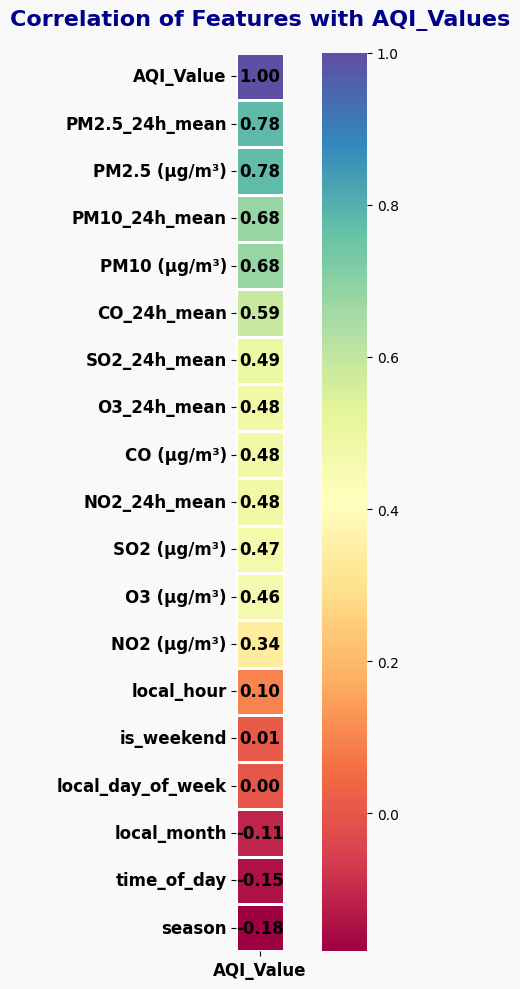

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select only numeric columns relevant to pollution
numeric_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
                'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'local_hour', 'local_month',
                'local_day_of_week', 'is_weekend', 'season', 'time_of_day', 'AQI_Value','PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean', 'SO2_24h_mean',
                'O3_24h_mean', 'CO_24h_mean', ]

# Correlation with dependent variable (CCME_Values)
corr = df_CTGAN[numeric_cols].corr()['AQI_Value'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10), facecolor="#f9f9f9")

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="Spectral",
    cbar=True,
    fmt=".2f",
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    linewidths=0.8,
    linecolor="white",
    square=True
)

# Titles and labels styling
plt.title(
    "Correlation of Features with AQI_Values",
    fontsize=16,
    fontweight="bold",
    color="darkblue",
    pad=20
)

plt.xticks(fontsize=12, weight="bold", color="black")
plt.yticks(fontsize=12, weight="bold", color="black", rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2621/1576637279.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df_CTGAN.groupby('AQI_Category', observed=True).apply(


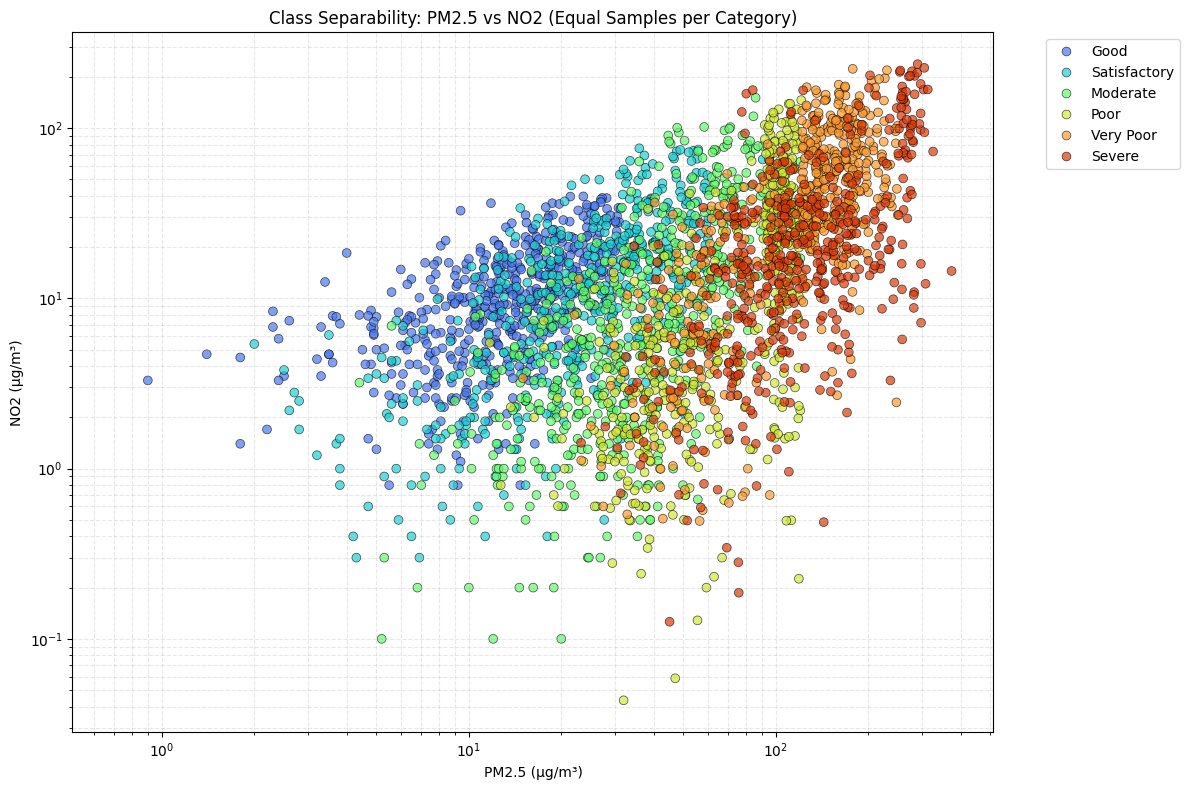

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STRATIFIED SAMPLING FOR CLEAR VISUALIZATION
# ---------------------------------------------------------

# 1. Take 500 random samples from EACH category
# (If a category has less than 500, it takes all of them)
stratified_sample = df_CTGAN.groupby('AQI_Category', observed=True).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
).reset_index(drop=True)

# 2. Plot the balanced data
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=stratified_sample,
    x='PM2.5 (µg/m³)',
    y='NO2 (µg/m³)',
    hue='AQI_Category',
    palette='turbo',  # 'turbo' gives very distinct high-contrast colors
    alpha=0.7,
    edgecolor='k',    # Adds a black border to dots for clarity
    s=40              # Slightly larger dots
)

plt.title('Class Separability: PM2.5 vs NO2 (Equal Samples per Category)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

/tmp/ipykernel_2621/3719438859.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


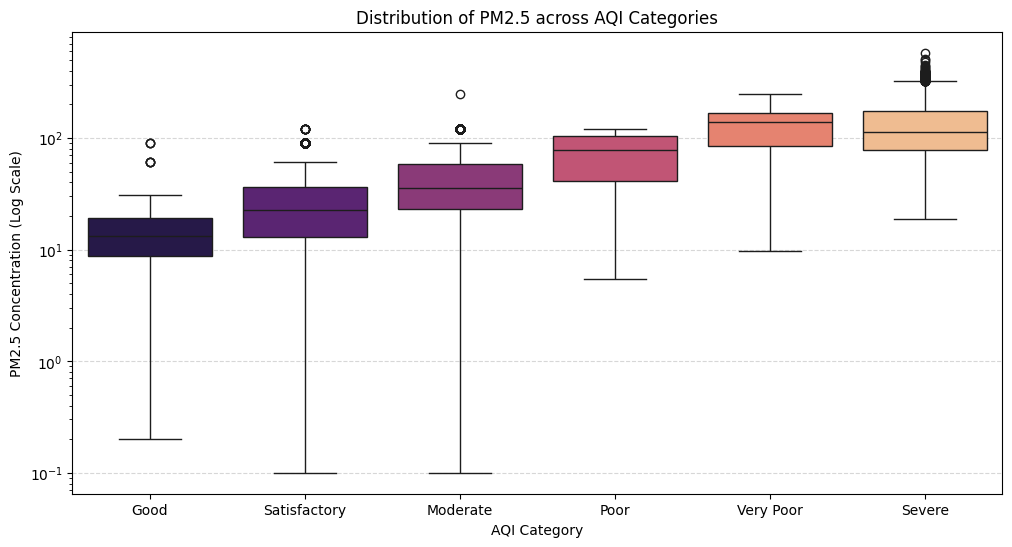

In [ ]:
plt.figure(figsize=(12, 6))

# We use PM2.5 as it's the main driver
sns.boxplot(
    data=df_CTGAN[df_CTGAN['AQI_Value'] > 0], # Filter bugs if any
    x='AQI_Category',
    y='PM2.5 (µg/m³)',
    palette='magma'
)

plt.title('Distribution of PM2.5 across AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('PM2.5 Concentration (Log Scale)')
plt.yscale('log') # Crucial for pollution data
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

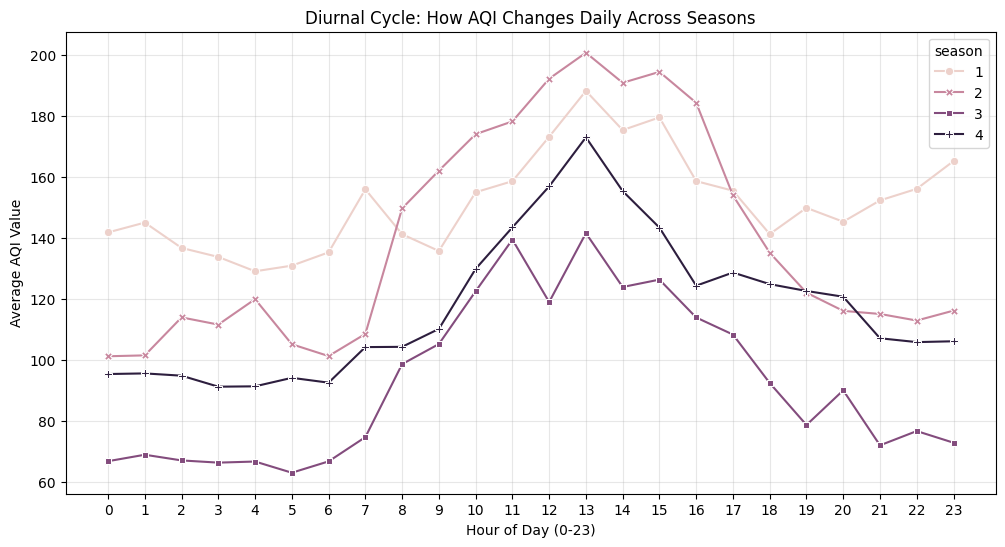

In [ ]:
plt.figure(figsize=(12, 6))

# Plot AQI trends over the day, split by Season
sns.lineplot(
    data=df_CTGAN.sample(n=len(df_CTGAN)), # Use all available data for smooth lines
    x='local_hour',
    y='AQI_Value',
    hue='season',
    style='season',
    markers=True,
    dashes=False,
    errorbar=None # Updated from ci=None to address FutureWarning
)

plt.title('Diurnal Cycle: How AQI Changes Daily Across Seasons')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average AQI Value')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

BUILDING THE ENSEMBLE MODEL

In [ ]:
# SPLITTING AND DEFINING X & y

df_CTGAN = df_CTGAN.sort_values(by=['timestamp']).reset_index(drop=True)

features = [
    # Geography
    'Latitude', 'Longitude',
    # Pollutants
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)',
    # 24h Averages
    'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean',
    'SO2_24h_mean', 'O3_24h_mean', 'CO_24h_mean',
    # Time Features
    'local_month', 'local_hour', 'local_day_of_week',
    'hour_sin', 'hour_cos', 'is_weekend', 'season', 'time_of_day'
]


print(f"Total Features Selected: {len(features)}")

# Define Target
target = 'AQI_Value'

#  Calculate Split (85% Train, 15% Test)
split_index = int(len(df_CTGAN) * 0.85)

# Create Train/Test Sets
X_train = df_CTGAN.iloc[:split_index][features]
y_train = df_CTGAN.iloc[:split_index][target]

X_test = df_CTGAN.iloc[split_index:][features]
y_test = df_CTGAN.iloc[split_index:][target]

print(f"Training Data (Past):   {X_train.shape}")
print(f"Testing Data (Future):  {X_test.shape}")

Total Features Selected: 22
Training Data (Past):   (792336, 22)
Testing Data (Future):  (139824, 22)


In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# TRAIN MODEL 1 - LIGHTGBM

print("1. Initializing LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

print("2. Training (Fitting) on Past Data...")
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print("3. Predicting on Future Data...")
y_pred_lgb = lgb_model.predict(X_test)

# EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae = mean_absolute_error(y_test, y_pred_lgb)

print("\n--- LightGBM Performance ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f}")
print(f"MAE (Mean Absolute Error):      {mae:.2f}")

1. Initializing LightGBM...
2. Training (Fitting) on Past Data...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3205
[LightGBM] [Info] Number of data points in the train set: 792336, number of used features: 22
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 128.826410
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 6.15557	valid_0's l2: 37.891
[200]	valid_0's rmse: 5.56372	valid_0's l2: 30.955
[300]	valid_0's rmse: 5.43307	valid_0's l2: 29.5183
[400]	valid_0's rmse: 5.35163	valid_0's l2: 28.64
[500]	valid_0's rmse: 5.30239	valid_0's l2: 28.1153
[600]	valid_0's rmse: 5.27068	valid_0's l2: 27.7

In [ ]:
import xgboost as xgb

# TRAIN MODEL 2 - XGBOOST

print("1. Initializing XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("2. Training XGBoost (This might take slightly longer)...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("3. Predicting with XGBoost...")
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("\n--- XGBoost Performance ---")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")

1. Initializing XGBoost...
2. Training XGBoost (This might take slightly longer)...
[0]	validation_0-rmse:82.98824
[100]	validation_0-rmse:6.48388
[200]	validation_0-rmse:6.43730
[300]	validation_0-rmse:6.44008
[400]	validation_0-rmse:6.45324
[500]	validation_0-rmse:6.46053
[600]	validation_0-rmse:6.47619
[700]	validation_0-rmse:6.48223
[800]	validation_0-rmse:6.48649
[900]	validation_0-rmse:6.48556
[999]	validation_0-rmse:6.48850
3. Predicting with XGBoost...

--- XGBoost Performance ---
RMSE: 6.49
MAE:  1.20


In [ ]:
# ENSEMBLE (THE VOTING REGRESSOR)

print("Averaging Predictions...")
final_predictions = (0.5 * y_pred_lgb) + (0.5 * y_pred_xgb)

# Evaluation
ensemble_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
ensemble_mae = mean_absolute_error(y_test, final_predictions)

print("\n=== FINAL ENSEMBLE RESULTS ===")
print(f"LightGBM RMSE: {rmse:.4f}")
print(f"XGBoost RMSE:  {rmse_xgb:.4f}")
print("-----------------------------")
print(f"ENSEMBLE RMSE: {ensemble_rmse:.4f}")
print(f"ENSEMBLE MAE:  {ensemble_mae:.4f}")

Averaging Predictions...

=== FINAL ENSEMBLE RESULTS ===
LightGBM RMSE: 5.2092
XGBoost RMSE:  6.4885
-----------------------------
ENSEMBLE RMSE: 5.3900
ENSEMBLE MAE:  1.0276


SHAP ANALYSIS

In [ ]:
import shap
print("1. Preparing SHAP Explainer...")
# TreeExplainer is optimized for LightGBM
explainer = shap.TreeExplainer(lgb_model)

print("2. Calculating SHAP values (Sampling 10000 rows)...")
X_shap_sample = X_test.sample(n=1000, random_state=42)
shap_values = explainer.shap_values(X_shap_sample)

1. Preparing SHAP Explainer...
2. Calculating SHAP values (Sampling 10000 rows)...


3. Generating Plot 1: Summary Plot...


/tmp/ipykernel_2621/1200738408.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap_sample, show=False)


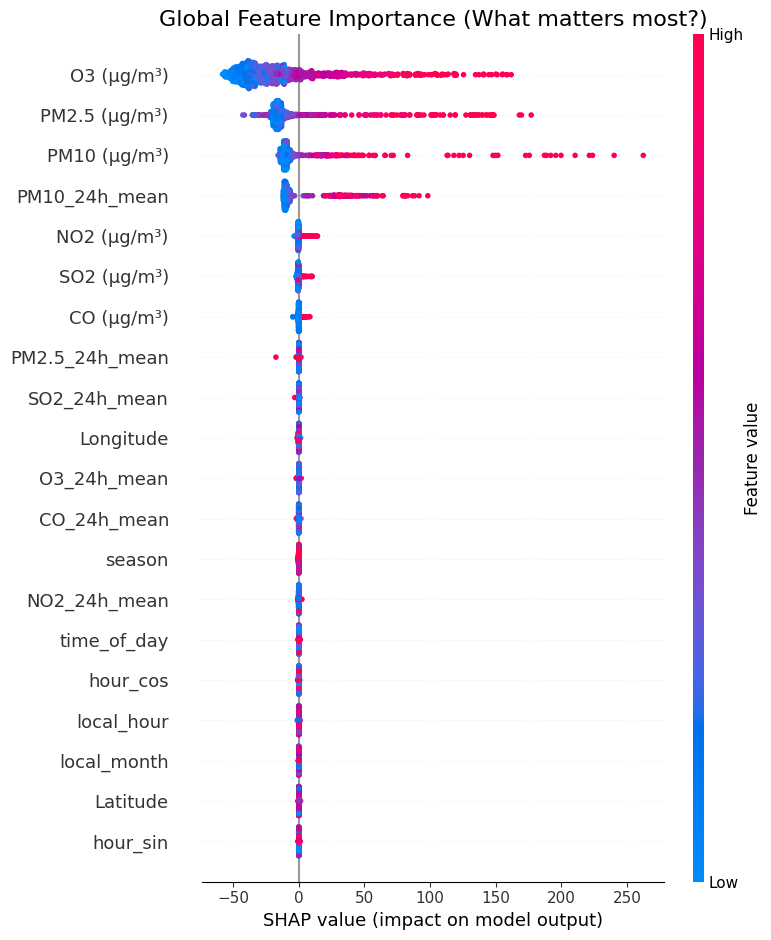

In [ ]:
# PLOT 1: SUMMARY PLOT
print("3. Generating Plot 1: Summary Plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("Global Feature Importance (What matters most?)", fontsize=16)
plt.tight_layout()
plt.show()

 Generating Plot 2: Category Bar Plot...


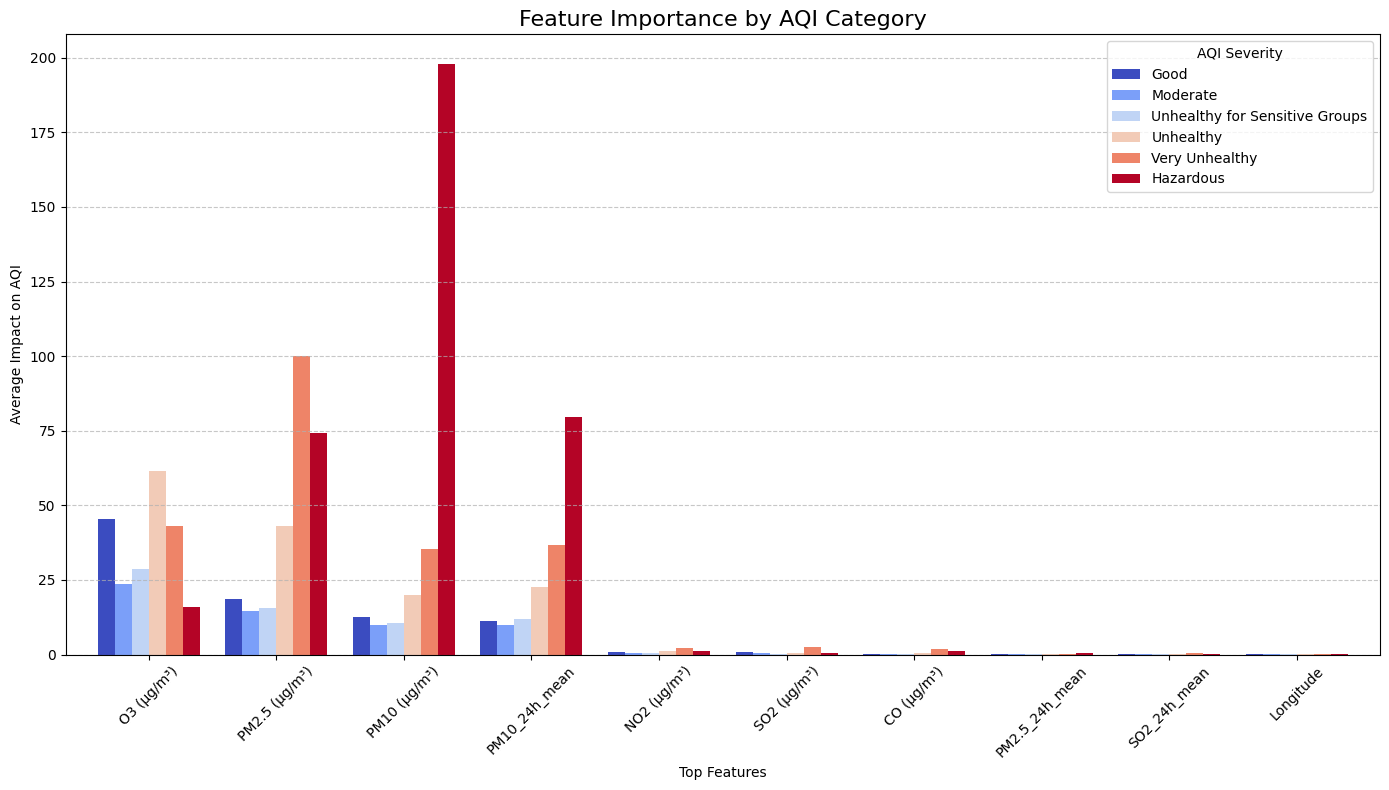

In [ ]:
# PLOT 2: AQI CATEGORY BAR PLOT
print(" Generating Plot 2: Category Bar Plot...")
# Create DataFrame of absolute SHAP impacts
df_shap = pd.DataFrame(np.abs(shap_values), columns=X_shap_sample.columns)

# Get predictions to categorize the sample
preds = lgb_model.predict(X_shap_sample)

# Binning logic (CPCB Standards)
bins = [0, 50, 100, 200, 300, 400, 5000]
labels = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy','Very Unhealthy','Hazardous']
df_shap['AQI_Category'] = pd.cut(preds, bins=bins, labels=labels)

# Find Top 5 features by impact
top_10_features = df_shap.drop(columns=['AQI_Category']).mean().sort_values(ascending=False).head(10).index

# Group by Category and Plot
plot_data = df_shap.groupby('AQI_Category', observed=False)[top_10_features].mean().T

ax = plot_data.plot(kind='bar', figsize=(14, 8), width=0.8, colormap='coolwarm')
plt.title("Feature Importance by AQI Category", fontsize=16)
plt.ylabel("Average Impact on AQI")
plt.xlabel("Top Features")
plt.legend(title="AQI Severity")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

5. Generating Plot 3: Dependence Subplots...


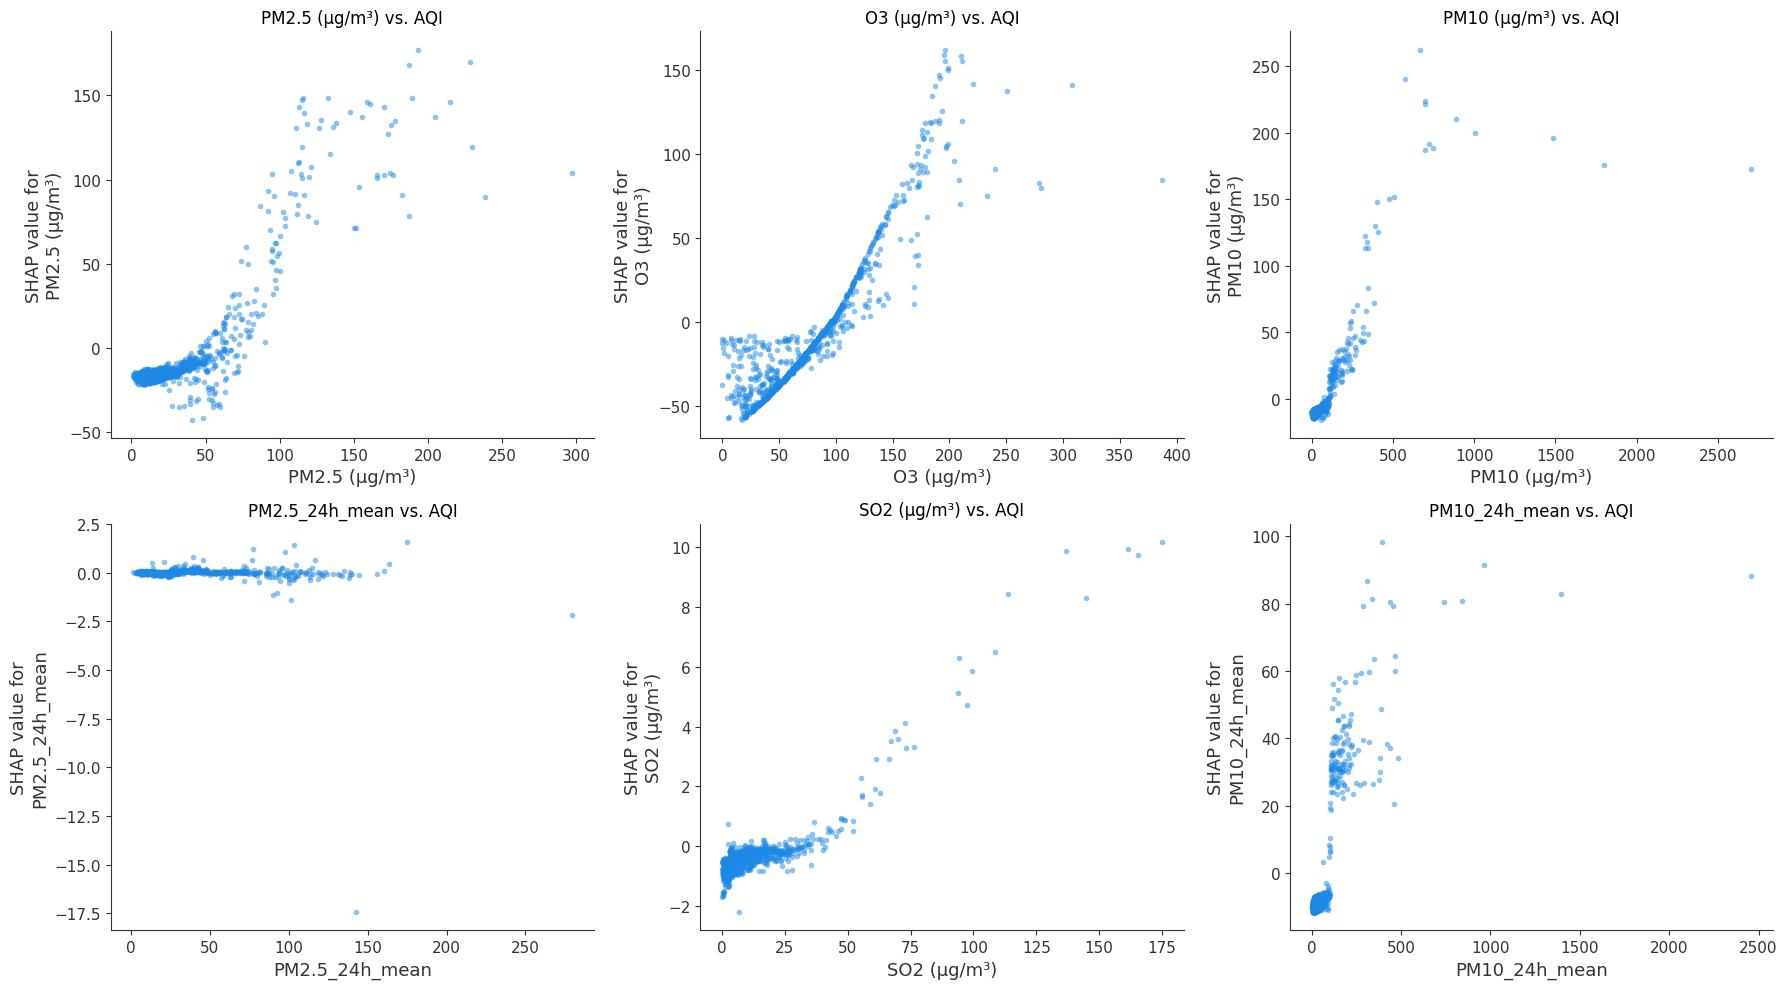

In [ ]:
import matplotlib.pyplot as plt

# Define the exact features you want to plot
features_to_plot = [
    'PM2.5 (µg/m³)',
    'O3 (µg/m³)',
    'PM10 (µg/m³)',
    'PM2.5_24h_mean',
    'SO2 (µg/m³)',
    'PM10_24h_mean'
]

print("5. Generating Plot 3: Dependence Subplots...")

#  Create a grid of subplots (2 rows, 3 columns = 6 plots)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

axes = axes.flatten()

# Loop through your features and draw each one in its assigned box
for i, feature in enumerate(features_to_plot):
    shap.dependence_plot(
        feature,
        shap_values,
        X_shap_sample,
        interaction_index=None,
        alpha=0.5,
        ax=axes[i],
        show=False
    )
    # Add a clean title to each subplot
    axes[i].set_title(f"{feature} vs. AQI", fontsize=12)

plt.tight_layout()
plt.show()

6. Generating Plot 4: Waterfall Plot (Single Prediction)...


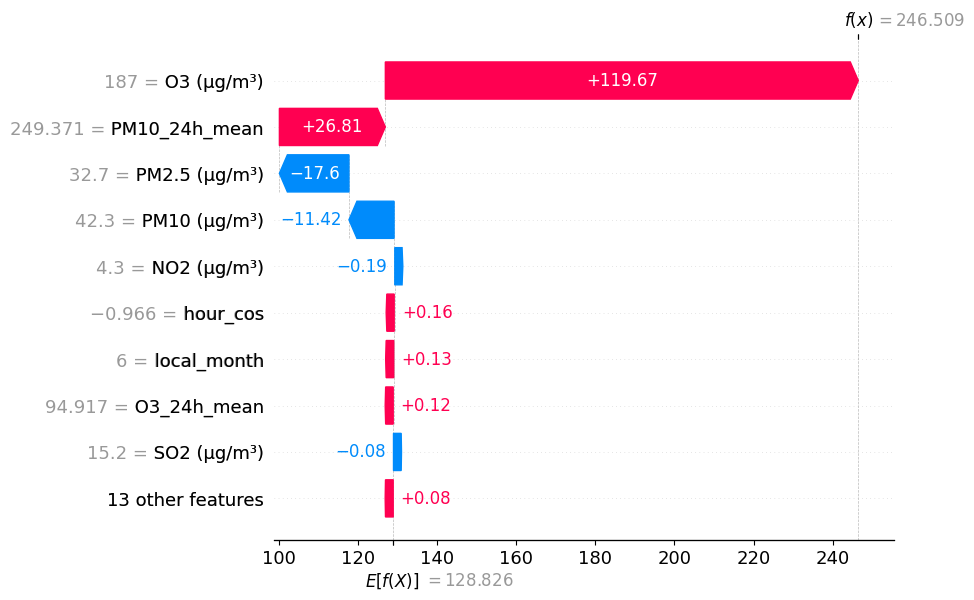

In [ ]:
#  PLOT 4: WATERFALL PLOT
print("6. Generating Plot 4: Waterfall Plot (Single Prediction)...")
shap_object = explainer(X_shap_sample)
shap.plots.waterfall(shap_object[0])